Dataset shape: (50000, 21)
Numerical columns: ['CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']
Categorical columns: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular']

Missing values before preprocessing:
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
dtype: int64

Processed shape: (50000, 41)
SVD shape: (50000, 30)

Running t-SNE...


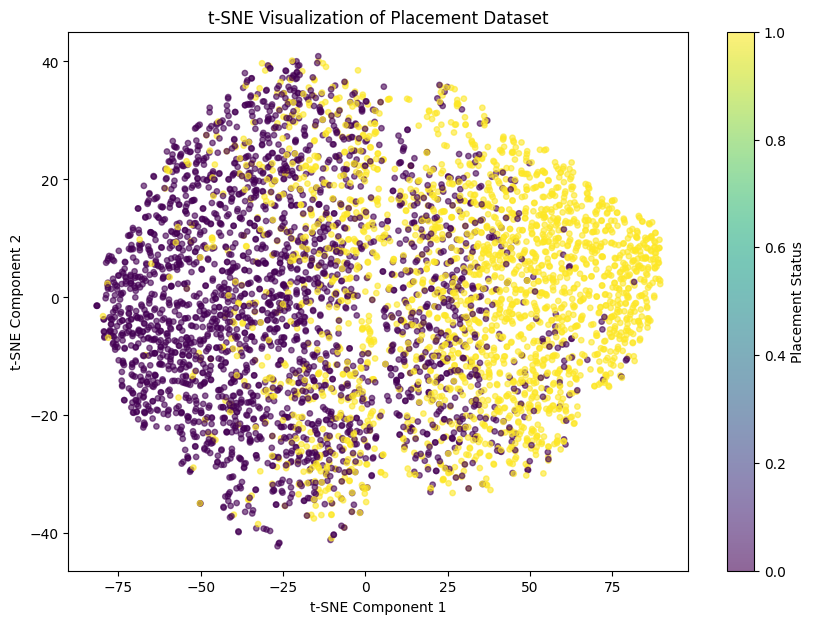

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("/content/placement_predict_50k_adjusted (1).csv")

print("Dataset shape:", df.shape)

# ==========================================
# 2. REMOVE TARGET AND ANOMALY COLUMNS
# ==========================================

X = df.drop(
    columns=["PlacementStatus", "IsAnomaly"],
    errors="ignore"
)

# ==========================================
# 3. IDENTIFY COLUMN TYPES
# ==========================================

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# ==========================================
# 4. CHECK MISSING VALUES
# ==========================================

print("\nMissing values before preprocessing:")
print(X.isnull().sum())

# ==========================================
# 5. NUMERICAL PREPROCESSING
# ==========================================

numeric_pipeline = [
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
]

# ==========================================
# 6. CATEGORICAL PREPROCESSING
# ==========================================

categorical_pipeline = [
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
]

# ==========================================
# 7. COMBINE PREPROCESSING
# ==========================================

from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(numeric_pipeline),
            numerical_cols
        ),
        (
            "cat",
            Pipeline(categorical_pipeline),
            categorical_cols
        )
    ]
)

# ==========================================
# 8. PREPROCESS DATA
# ==========================================

X_processed = preprocessor.fit_transform(X)

print("\nProcessed shape:", X_processed.shape)

# ==========================================
# 9. REDUCE FEATURES USING SVD
# ==========================================

svd = TruncatedSVD(
    n_components=30,
    random_state=42
)

X_reduced = svd.fit_transform(X_processed)

print("SVD shape:", X_reduced.shape)

# ==========================================
# 10. TAKE 5000 SAMPLES FOR t-SNE
# ==========================================

sample_size = min(5000, len(df))

sample_indices = df.sample(
    n=sample_size,
    random_state=42
).index

X_sample = X_reduced[sample_indices]

y_sample = df.loc[
    sample_indices,
    "PlacementStatus"
]

# ==========================================
# 11. CONVERT PLACEMENT STATUS TO NUMBERS
# ==========================================

y_numeric = pd.factorize(y_sample)[0]

# ==========================================
# 12. APPLY t-SNE
# ==========================================

print("\nRunning t-SNE...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

print("t-SNE completed successfully!")
print("t-SNE shape:", X_tsne.shape)

# ==========================================
# 13. VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_numeric,
    alpha=0.6,
    s=15
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Placement Dataset")

plt.colorbar(
    scatter,
    label="Placement Status"
)

plt.show()